# TD1

# Phase1

In [1]:
import spacy
import trafilatura
import pandas as pd
import httpx

print("Tout fonctionne !")

Tout fonctionne !


# URL

In [2]:
# Librairies nécessaires

import json

# URLs des 8 plus grandes villes françaises
urls = [
    "https://fr.wikipedia.org/wiki/Toulouse",
    "https://fr.wikipedia.org/wiki/Paris",
    "https://fr.wikipedia.org/wiki/Lyon",
    "https://fr.wikipedia.org/wiki/Marseille",
    "https://fr.wikipedia.org/wiki/Nice",
    "https://fr.wikipedia.org/wiki/Nantes",
    "https://fr.wikipedia.org/wiki/Lille",
    "https://fr.wikipedia.org/wiki/Montpellier"
]

print("Cellule 1 OK : Imports et URLs prêts")

Cellule 1 OK : Imports et URLs prêts


In [3]:
# Vérifie si le texte contient plus de 500 mots
def is_useful(text, min_words=500):
    if text is None:
        return False
    return len(text.split()) >= min_words

print("Cellule 2 OK : Fonction is_useful prête")

Cellule 2 OK : Fonction is_useful prête


In [4]:
# Récupère le texte principal d'une page avec Trafilatura
def extract_text(url):
    downloaded = trafilatura.fetch_url(url)
    if downloaded:
        text = trafilatura.extract(downloaded)
        return text
    return None

print("Cellule 3 OK : Fonction extract_text prête")

Cellule 3 OK : Fonction extract_text prête


# Crawler + cleaning + NER

In [298]:
# Sauvegarde la liste de dictionnaires dans un fichier JSONL
def save_jsonl(data, filename="crawler_output.jsonl"):
    with open(filename, "w", encoding="utf-8") as f:
        for entry in data:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print("Cellule 4 OK : Fonction save_jsonl prête")

Cellule 4 OK : Fonction save_jsonl prête


In [6]:
# Liste pour stocker les résultats
data = []

for url in urls:
    text = extract_text(url)
    if is_useful(text):
        data.append({"url": url, "text": text})
        print(f"Page utile sauvegardée : {url}")
    else:
        print(f"Page ignorée (moins de 500 mots) : {url}")

# Sauvegarde dans JSONL
save_jsonl(data)
print(f"Phase 1 terminée : {len(data)} pages sauvegardées dans crawler_output.jsonl")

Page utile sauvegardée : https://fr.wikipedia.org/wiki/Toulouse
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Paris
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Lyon
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Marseille
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Nice
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Nantes
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Lille
Page utile sauvegardée : https://fr.wikipedia.org/wiki/Montpellier
Phase 1 terminée : 8 pages sauvegardées dans crawler_output.jsonl


# Phase2

In [7]:
import spacy
import pandas as pd
import json

# Charge le modèle léger CPU-only
nlp = spacy.load("en_core_web_sm")

print("Phase 2 OK : spaCy prêt")

Phase 2 OK : spaCy prêt


In [8]:
# Lire le fichier crawler_output.jsonl
data = []
with open("crawler_output.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print(f"{len(data)} pages chargées pour extraction NER")

8 pages chargées pour extraction NER


In [9]:
# On ne garde que PERSON, ORG, GPE, DATE
def extract_entities(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
            entities.append({"text": ent.text, "label": ent.label_})
    return entities

print("Fonction extract_entities prête")

Fonction extract_entities prête


In [10]:
results = []

for page in data:
    url = page["url"]
    text = page["text"]
    entities = extract_entities(text)
    for ent in entities:
        results.append({
            "entity": ent["text"],
            "type": ent["label"],
            "source_url": url
        })

print(f"{len(results)} entités extraites")

34222 entités extraites


In [11]:
df = pd.DataFrame(results)
df.to_csv("extracted_knowledge.csv", index=False, encoding="utf-8")
print("extracted_knowledge.csv créé ✅")

extracted_knowledge.csv créé ✅


In [12]:
relations = []

for page in data:
    text = page["text"]
    doc = nlp(text)
    for sent in doc.sents:
        sent_ents = [ent for ent in sent.ents if ent.label_ in ["PERSON","ORG","GPE","DATE"]]
        if len(sent_ents) >= 2:
            # Exemple simple : relier la première entité à la deuxième
            relations.append({
                "source": sent_ents[0].text,
                "relation": "connected_to",  # placeholder, on peut essayer d'utiliser le verbe
                "target": sent_ents[1].text,
                "sentence": sent.text
            })

print(f"{len(relations)} relations candidates trouvées")

7006 relations candidates trouvées


In [13]:
import os
os.listdir()

['.ipynb_checkpoints',
 'crawler.py',
 'crawler_output.jsonl',
 'extracted_knowledge.csv',
 'webdataa.ipynb']

# TD4

# Phase1

In [15]:
!pip install rdflib

   ---------------------------------------- 0.0/615.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/615.4 kB ? eta -:--:--
   ---------------------------------------- 615.4/615.4 kB 2.8 MB/s  0:00:00

   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   -------------------- ------------------- 1/2 [rdflib]
   ---------------------------------------- 2/2 [rdflib]



In [16]:
import pandas as pd
import json
from rdflib import Graph, URIRef, Literal, Namespace, RDF

In [17]:
# Charger le CSV des entités
entities_df = pd.read_csv("extracted_knowledge.csv")
entities_df.head()

# Charger le JSONL du texte (optionnel si tu veux exploiter les textes pour relations)
jsonl_file = "crawler_output.jsonl"
pages = []
with open(jsonl_file, "r", encoding="utf-8") as f:
    for line in f:
        pages.append(json.loads(line))

# Vérifions le contenu du JSONL
pages[0]  # affiche la première page pour voir la structure

{'url': 'https://fr.wikipedia.org/wiki/Toulouse',
 'text': 'Toulouse\n| Toulouse | |||||\n| De haut en bas et de gauche à droite : le pont Saint-Pierre, une réplique de la fusée Ariane 5 à la Cité de l\'espace, la basilique Saint-Sernin, la place du Capitole, le premier Airbus A380 et le musée des Augustins. | |||||\nBlason |\nLogo |\n||||\n| Administration | |||||\n|---|---|---|---|---|---|\n| Pays | France | ||||\n| Région | Occitanie (préfecture) | ||||\n| Département | Haute-Garonne (préfecture) |\n||||\n| Arrondissement | Toulouse (chef-lieu) |\n||||\n| Intercommunalité | Toulouse Métropole (siège) |\n||||\n| Maire Mandat |\nJean-Luc Moudenc 2026-2032 |\n||||\n| Code postal | 31000, 31004, 31090, 31100, 31200, 31300, 31400 et 31500 | ||||\n| Code commune | 31555 | ||||\n| Démographie | |||||\n| Gentilé | Toulousains, Toulousaines | ||||\n| Population municipale |\n514 819 hab. (2023 ) | ||||\n| Densité | 4 352 hab./km2 | ||||\n| Population unité urbaine |\n1 093 783 hab. (2023) | 

In [25]:
!pip install unidecode

In [26]:
import re
import unidecode

In [27]:
def clean_entity_for_uri(entity):
    # remplacer les espaces par "_"
    uri = entity.replace(" ", "_")
    # supprimer tous les caractères non alphanumériques sauf "_"
    uri = re.sub(r'[^a-zA-Z0-9_]', '', uri)
    # transformer les accents en lettres simples
    uri = unidecode.unidecode(uri)
    return uri

In [28]:
# Créer le graphe RDF
g = Graph()
EX = Namespace("http://example.org/")
g.bind("ex", EX)

# Ajouter les entités
for index, row in entities_df.iterrows():
    clean_name = clean_entity_for_uri(row['entity'])
    entity_uri = EX[clean_name]
    
    # Ajouter le type si PERSON, ORG ou GPE
    if row['type'] in ['PERSON', 'ORG', 'GPE']:
        g.add((entity_uri, RDF.type, EX[row['type']]))
    
    # Exemple de relation simple : toutes les GPE sont en France
    if row['type'] == "GPE":
        g.add((entity_uri, EX.locatedIn, EX.France))

In [29]:
# Nombre total de triplets
print(f"Nombre de triplets dans le graphe : {len(g)}\n")

# Afficher les 20 premiers triplets pour vérifier
for i, triple in enumerate(g):
    if i >= 20:
        break
    print(triple)

Nombre de triplets dans le graphe : 16883

(rdflib.term.URIRef('http://example.org/de_la_dette'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/PERSON'))
(rdflib.term.URIRef('http://example.org/taux_de_criminalit_de_la'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/PERSON'))
(rdflib.term.URIRef('http://example.org/Stolpersteine'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/PERSON'))
(rdflib.term.URIRef('http://example.org/HautesAlpes'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/PERSON'))
(rdflib.term.URIRef('http://example.org/aucun_autre_candidat'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://example.org/PERSON'))
(rdflib.term.URIRef('http://example.org/Beaumont'), rdflib

# Ontology

In [30]:
# Sauvegarder le graphe RDF au format Turtle
g.serialize("initial_KB.ttl", format="turtle")
print("Graphe RDF sauvegardé sous 'initial_KB.ttl'")

Graphe RDF sauvegardé sous 'initial_KB.ttl'


# Phase2

In [34]:
from rdflib import Graph, Namespace, RDF, OWL, URIRef

# Charger le graphe RDF créé à Step 1
g = Graph()
g.parse("initial_KB.ttl", format="turtle")

EX = Namespace("http://example.org/")
g.bind("ex", EX)

In [35]:
# Lister toutes les entités uniques
entities = set(g.subjects(RDF.type, None))
print(f"Nombre d'entités privées : {len(entities)}")
list(entities)[:10]  # Affiche les 10 premières pour vérifier

Nombre d'entités privées : 15404


[rdflib.term.URIRef('http://example.org/Metronews'),
 rdflib.term.URIRef('http://example.org/Le_Banquet'),
 rdflib.term.URIRef('http://example.org/Emmanuel_Le'),
 rdflib.term.URIRef('http://example.org/celui_de_lhtel_de_Rambouillet'),
 rdflib.term.URIRef('http://example.org/une_ville_de_moines'),
 rdflib.term.URIRef('http://example.org/JosephRosalinde_Rancher'),
 rdflib.term.URIRef('http://example.org/vivier_de_crativit_avec_lmergence_dacteurs'),
 rdflib.term.URIRef('http://example.org/RenBougnol'),
 rdflib.term.URIRef('http://example.org/Paul_Molga'),
 rdflib.term.URIRef('http://example.org/le_code_Tibriade')]

In [39]:
!pip install SPARQLWrapper

In [40]:
from SPARQLWrapper import SPARQLWrapper, JSON

# Endpoint Wikidata
sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
sparql.setReturnFormat(JSON)

print("ok")

ok


In [41]:
def wikidata_search(entity_label):
    """
    Cherche une entité dans Wikidata par son label en français.
    Retourne l'URI si trouvée, sinon None.
    """
    query = f"""
    SELECT ?item ?itemLabel WHERE {{
      ?item rdfs:label "{entity_label}"@fr .
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "fr". }}
    }}
    LIMIT 1
    """
    sparql.setQuery(query)
    results = sparql.query().convert()
    bindings = results["results"]["bindings"]
    if bindings:
        # Retourne URI + confiance fictive (ici 0.99 si trouvé)
        return bindings[0]["item"]["value"], 0.99
    else:
        return None, 0.0


print("ok")

ok


In [48]:
print(len(entities))
print(len(triple))

15404
3


In [46]:
import pandas as pd
from rdflib import URIRef, RDF, OWL

# Convertir le set en liste et limiter aux 200 premières entités
entities_list = list(entities)
entities_subset = entities_list[:200]

mapping = []

for entity in entities_subset:
    label = entity.split('/')[-1]  # Nom simple de l'URI, ex: 'MarieCurie'
    
    try:
        wd_uri, confidence = wikidata_search(label)
    except Exception as e:
        print(f"Erreur pour {label}: {e}")
        wd_uri, confidence = None, 0.0  # En cas d'erreur HTTP ou timeout
    
    if wd_uri:
        # Ajouter le lien owl:sameAs dans le graphe
        g.add((entity, OWL.sameAs, URIRef(wd_uri)))
    else:
        # Nouvelle entité → ajouter une définition RDF minimale
        g.add((entity, RDF.type, EX["NewEntity"]))
    
    # Ajouter la ligne dans la table de mapping
    mapping.append([entity, wd_uri if wd_uri else "N/A", confidence])

# Convertir en DataFrame et sauvegarder
mapping_df = pd.DataFrame(mapping, columns=["Private Entity", "External URI", "Confidence"])
mapping_df.to_csv("entity_mapping_200.csv", index=False)
mapping_df.head(10)

,Private Entity,External URI,Confidence
0,http://example.org/Metronews,http://www.wikidata.org/entity/Q28493296,0.99
1,http://example.org/Le_Banquet,N/A,0.00
2,http://example.org/Emmanuel_Le,N/A,0.00
3,http://example.org/celui_de_lhtel_de_Rambouillet,N/A,0.00
4,http://example.org/une_ville_de_moines,N/A,0.00
5,http://example.org/JosephRosalinde_Rancher,N/A,0.00
6,http://example.org/vivier_de_crativit_avec_lme...,N/A,0.00
7,http://example.org/RenBougnol,N/A,0.00
8,http://example.org/Paul_Molga,N/A,0.00
9,http://example.org/le_code_Tibriade,N/A,0.00


In [53]:
import pandas as pd
from rdflib import URIRef, RDF, OWL
import time
from SPARQLWrapper import SPARQLWrapper, JSON

# Préparer la liste des entités (convertir le set en liste si nécessaire)
entities_list = list(entities)

# Définir le sous-ensemble à traiter (par exemple 2000)
start_index = 0    # tu peux changer si tu reprends plus tard
end_index = 2000
entities_subset = entities_list[start_index:end_index]

# Initialiser le mapping et le SPARQL endpoint
mapping = []
sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
sparql.setReturnFormat(JSON)

# Fonction pour rechercher sur Wikidata
def wikidata_search(label):
    try:
        query = f"""
        SELECT ?item WHERE {{
          ?item rdfs:label "{label}"@en .
        }}
        LIMIT 1
        """
        sparql.setQuery(query)
        results = sparql.query().convert()
        bindings = results["results"]["bindings"]
        if bindings:
            return bindings[0]["item"]["value"], 0.99  # confiance fictive
        else:
            return None, 0.0
    except Exception as e:
        print(f"Erreur pour {label}: {e}")
        return None, 0.0

# Boucle principale
for idx, entity in enumerate(entities_subset, start=start_index+1):
    label = entity.split('/')[-1]
    wd_uri, confidence = wikidata_search(label)
    
    if wd_uri:
        g.add((entity, OWL.sameAs, URIRef(wd_uri)))
    else:
        g.add((entity, RDF.type, EX["NewEntity"]))
    
    mapping.append([entity, wd_uri if wd_uri else "N/A", confidence])
    
    # Affichage de progression toutes les 10 entités
    if idx % 30 == 0:
        print(f"Traitée entité {idx}/{end_index}")
    
    # Pause pour éviter 429 Too Many Requests
    time.sleep(0.5)

# Sauvegarder le CSV partiel
mapping_df = pd.DataFrame(mapping, columns=["Private Entity", "External URI", "Confidence"])
mapping_df.to_csv(f"entity_mapping_{start_index+1}_{end_index}.csv", index=False)
print("CSV partiel sauvegardé.")

Traitée entité 30/2000
Traitée entité 60/2000
Traitée entité 90/2000
Traitée entité 120/2000
Traitée entité 150/2000
Traitée entité 180/2000
Traitée entité 210/2000
Traitée entité 240/2000
Traitée entité 270/2000
Traitée entité 300/2000
Traitée entité 330/2000
Traitée entité 360/2000
Traitée entité 390/2000
Traitée entité 420/2000
Traitée entité 450/2000
Traitée entité 480/2000
Traitée entité 510/2000
Traitée entité 540/2000
Traitée entité 570/2000
Erreur pour AixMarseille__OCDE: HTTP Error 502: Bad Gateway
Traitée entité 600/2000
Traitée entité 630/2000
Traitée entité 660/2000
Traitée entité 690/2000
Traitée entité 720/2000
Traitée entité 750/2000
Erreur pour est_de_144_C: HTTP Error 429: Too Many Requests
Traitée entité 780/2000
Traitée entité 810/2000
Traitée entité 840/2000
Erreur pour Breil__Barberie: HTTP Error 502: Bad Gateway
Erreur pour dpoque: HTTP Error 502: Bad Gateway
Traitée entité 870/2000
Erreur pour dric_Guirado: HTTP Error 429: Too Many Requests
Traitée entité 900/200

In [54]:
g.serialize("linked_KB.ttl", format="turtle")
print("Graphe RDF mis à jour sauvegardé sous 'linked_KB.ttl'")

Graphe RDF mis à jour sauvegardé sous 'linked_KB.ttl'


In [55]:
from rdflib import Graph

# Charger le graphe RDF existant
g = Graph()
g.parse("linked_KB.ttl", format="turtle")

print("Graphe chargé avec succès")
print("Nombre de triplets :", len(g))

Graphe chargé avec succès
Nombre de triplets : 18900


In [56]:
from SPARQLWrapper import SPARQLWrapper, JSON

# Initialiser le endpoint Wikidata
sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
sparql.setReturnFormat(JSON)

print("SPARQL prêt à être utilisé")

SPARQL prêt à être utilisé


# Phase3

In [57]:
predicates = set(g.predicates())

print("Nombre de predicates :", len(predicates))

for p in list(predicates)[:10]:
    print(p)

Nombre de predicates : 3
http://www.w3.org/1999/02/22-rdf-syntax-ns#type
http://example.org/locatedIn
http://www.w3.org/2002/07/owl#sameAs


In [59]:
query = """
SELECT ?property ?propertyLabel WHERE {
  ?property a wikibase:Property .
  ?property rdfs:label ?propertyLabel .
  
  FILTER(CONTAINS(LCASE(?propertyLabel), "location"))
  FILTER(LANG(?propertyLabel) = "en")
}
LIMIT 10
"""

sparql.setQuery(query)
results = sparql.query().convert()

for result in results["results"]["bindings"]:
    print(result["property"]["value"], "-", result["propertyLabel"]["value"])

http://www.wikidata.org/entity/P625 - coordinate location
http://www.wikidata.org/entity/P189 - location of discovery
http://www.wikidata.org/entity/P654 - direction relative to location
http://www.wikidata.org/entity/P276 - location
http://www.wikidata.org/entity/P740 - location of formation
http://www.wikidata.org/entity/P609 - terminus location
http://www.wikidata.org/entity/P774 - FIPS 55-3 (locations in the US)
http://www.wikidata.org/entity/P1943 - location map
http://www.wikidata.org/entity/P1944 - relief location map
http://www.wikidata.org/entity/P1997 - Facebook location ID


# Alignment scripts and file

In [60]:
from rdflib import URIRef, OWL

EX = Namespace("http://example.org/")

# Ton predicate
my_predicate = EX.locatedIn

# Predicate Wikidata choisi (ex: P131)
wikidata_predicate = URIRef("http://www.wikidata.org/prop/direct/P131")

# Ajouter l’alignement
g.add((my_predicate, OWL.equivalentProperty, wikidata_predicate))

print("Alignment ajouté !")

Alignment ajouté !


In [61]:
g.serialize("aligned_KB.ttl", format="turtle")
print("Graphe sauvegardé sous 'aligned_KB.ttl'")

Graphe sauvegardé sous 'aligned_KB.ttl'


# Phase4

In [67]:
from rdflib import OWL

aligned_entities = []

for s in g.subjects():
    for o in g.objects(s, OWL.sameAs):
        aligned_entities.append((s, str(o)))

print("Nombre d'entités alignées :", len(aligned_entities))

Nombre d'entités alignées : 538


# Expansion

In [68]:
import time
from rdflib import URIRef

max_entities = 100   #  commence avec 50
triples_added = 0

for i, (entity, wiki_uri) in enumerate(aligned_entities[:max_entities]):
    
    query = f"""
    SELECT ?p ?o WHERE {{
      <{wiki_uri}> ?p ?o .
    }}
    LIMIT 50
    """
    
    try:
        sparql.setQuery(query)
        results = sparql.query().convert()
        
        for result in results["results"]["bindings"]:
            p = URIRef(result["p"]["value"])
            o = URIRef(result["o"]["value"])
            
            g.add((URIRef(wiki_uri), p, o))
            triples_added += 1
        
        print(f"Entité {i+1}/{max_entities} → OK ({triples_added} triples)")
        time.sleep(1)
        
    except Exception as e:
        print("Erreur :", e)
        time.sleep(5)

Wikimedia disambiguation page does not look like a valid URI, trying to serialize this will break.
pagina di disambiguazione di un progetto Wikimedia does not look like a valid URI, trying to serialize this will break.
pachina de desambigación does not look like a valid URI, trying to serialize this will break.
صفحة توضيح لويكيميديا does not look like a valid URI, trying to serialize this will break.
صفحة توضيح ديال ويكيميديا does not look like a valid URI, trying to serialize this will break.
ৱিকিমিডিয়া দ্ব্যৰ্থতা দূৰীকৰণ পৃষ্ঠা does not look like a valid URI, trying to serialize this will break.
páxina de dixebra de Wikimedia does not look like a valid URI, trying to serialize this will break.
Уикимедия пояснителна страница does not look like a valid URI, trying to serialize this will break.
উইকিমিডিয়ার দ্ব্যর্থতা নিরসন পাতা does not look like a valid URI, trying to serialize this will break.
višeznačna odrednica na Wikimediji does not look like a valid URI, trying to serialize thi

Entité 1/100 → OK (50 triples)


Wikimedia disambiguation page does not look like a valid URI, trying to serialize this will break.
pagina di disambiguazione di un progetto Wikimedia does not look like a valid URI, trying to serialize this will break.
pachina de desambigación does not look like a valid URI, trying to serialize this will break.
صفحة توضيح لويكيميديا does not look like a valid URI, trying to serialize this will break.
صفحة توضيح ديال ويكيميديا does not look like a valid URI, trying to serialize this will break.
ৱিকিমিডিয়া দ্ব্যৰ্থতা দূৰীকৰণ পৃষ্ঠা does not look like a valid URI, trying to serialize this will break.
páxina de dixebra de Wikimedia does not look like a valid URI, trying to serialize this will break.
Уикимедия пояснителна страница does not look like a valid URI, trying to serialize this will break.
উইকিমিডিয়ার দ্ব্যর্থতা নিরসন পাতা does not look like a valid URI, trying to serialize this will break.
višeznačna odrednica na Wikimediji does not look like a valid URI, trying to serialize thi

Entité 2/100 → OK (100 triples)


Halaman disambiguasi does not look like a valid URI, trying to serialize this will break.


...

Entité 98/100 → OK (4671 triples)


Wikimedia disambiguation page does not look like a valid URI, trying to serialize this will break.
pagina di disambiguazione di un progetto Wikimedia does not look like a valid URI, trying to serialize this will break.
pachina de desambigación does not look like a valid URI, trying to serialize this will break.
صفحة توضيح لويكيميديا does not look like a valid URI, trying to serialize this will break.
صفحة توضيح ديال ويكيميديا does not look like a valid URI, trying to serialize this will break.
ৱিকিমিডিয়া দ্ব্যৰ্থতা দূৰীকৰণ পৃষ্ঠা does not look like a valid URI, trying to serialize this will break.
páxina de dixebra de Wikimedia does not look like a valid URI, trying to serialize this will break.
Уикимедия пояснителна страница does not look like a valid URI, trying to serialize this will break.
উইকিমিডিয়ার দ্ব্যর্থতা নিরসন পাতা does not look like a valid URI, trying to serialize this will break.
višeznačna odrednica na Wikimediji does not look like a valid URI, trying to serialize thi

Entité 99/100 → OK (4721 triples)


type of business entity in Spain; type of state-owned enterprise in Spain does not look like a valid URI, trying to serialize this will break.
Espainiako enpresa mota does not look like a valid URI, trying to serialize this will break.
ụdị ụlọ ọrụ azụmahịa na Spain; ụdị ụlọ ọrụ steeti nwere na Spain does not look like a valid URI, trying to serialize this will break.
tipo de organismo público de España does not look like a valid URI, trying to serialize this will break.
tipus d'organisme públic d'Espanya does not look like a valid URI, trying to serialize this will break.
pravna oblika državnih podjetij v Španiji does not look like a valid URI, trying to serialize this will break.
entidade pública empresarial does not look like a valid URI, trying to serialize this will break.
entidá pública empresarial does not look like a valid URI, trying to serialize this will break.
entitat pública empresarial does not look like a valid URI, trying to serialize this will break.
entidad pública emp

Entité 100/100 → OK (4771 triples)


In [71]:
query = """
SELECT ?s ?p ?o WHERE {
  ?s wdt:P31 ?o .
}
LIMIT 10000
"""

sparql.setQuery(query)
results = sparql.query().convert()

from rdflib import URIRef

count = 0
p = URIRef("http://www.wikidata.org/prop/direct/P31")

for result in results["results"]["bindings"]:
    s = URIRef(result["s"]["value"])
    o = URIRef(result["o"]["value"])
    
    g.add((s, p, o))
    count += 1

print("Triplets ajoutés :", count)

Triplets ajoutés : 10000


In [132]:
print(len(entities))
print("Nombre total de triplets uniques :", len(set(g)))

15404
Nombre total de triplets uniques : 32401
  Using cached pykeen-1.11.1-py3-none-any.whl.metadata (85 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached click_default_group-1.2.4-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached torch-2.11.0-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached more_click-0.1.3-py3-none-any.whl.metadata (14 kB)
  Using cached more_itertools-10.8.0-py3-none-any.whl.metadata (39 kB)
  Using cached pystow-0.8.3-py3-none-any.whl.metadata (17 kB)
  Using cached docdata-0.0.5-py3-none-any.whl.metadata (13 kB)
  Using cached class_resolver-0.7.1-py3-none-any.whl.metadata (19 kB)
  Using cached torch_max_mem-0.1.4-py3-none-any.whl.metadata

In [76]:
from rdflib import URIRef

valid_triples = []

for s, p, o in g:
    if isinstance(s, URIRef) and isinstance(p, URIRef) and isinstance(o, URIRef):
        valid_triples.append((s, p, o))

g_clean = Graph()
for triple in valid_triples:
    g_clean.add(triple)

print("Triplets après nettoyage des URI :", len(g_clean))

Triplets après nettoyage des URI : 32401


In [299]:
from urllib.parse import quote
from rdflib import Graph, URIRef, RDF, OWL

def safe_uri(uri):
    # Si c'est déjà un URIRef, on prend sa valeur
    if isinstance(uri, URIRef):
        uri = str(uri)
    # Encode les caractères spéciaux
    return URIRef(quote(uri, safe=":/#"))  # : / # restent intacts

# Créer un nouveau graphe propre
g_safe = Graph()

for s, p, o in g_clean:
    try:
        g_safe.add((safe_uri(s), safe_uri(p), safe_uri(o)))
    except Exception as e:
        print(f"Erreur sur le triplet ({s}, {p}, {o}) → {e}")

# RDF graph

In [81]:
g_safe.serialize("expanded_KB_clean.ttl", format="turtle")
print("Graphe RDF final nettoyé et URI encodées sauvegardé sous 'expanded_KB_clean.ttl'")

Graphe RDF final nettoyé et URI encodées sauvegardé sous 'expanded_KB_clean.ttl'


# TD5

# Part1

In [101]:
!pip install owlready2

In [102]:
from owlready2 import *

# Charger l'ontologie depuis le fichier
onto = get_ontology("file://family.owl").load()
print("Ontologie chargée :", onto)

Ontologie chargée : get_ontology("http://www.owl-ontologies.com/unnamed.owl#")


In [103]:
# Lister toutes les classes
print("Classes dans l'ontologie :")
for cls in onto.classes():
    print("-", cls.name)

# Lister toutes les propriétés de données (DataProperty)
print("\nPropriétés de données :")
for prop in onto.data_properties():
    print("-", prop.name)

Classes dans l'ontologie :
- Son
- Child
- Daughter
- Person
- Uncle
- Parent
- Male
- Grandmother
- Grandparents
- Female
- Grandfather
- Father
- Mother
- Sibling
- Brother
- Sister

Propriétés de données :
- age
- nationality
- name
- hasAge


In [105]:
# Récupérer la classe Person depuis l'ontologie
Person = onto.Person

with onto:
    # Créer oldPerson comme sous-classe de Person
    class oldPerson(Person):
        pass

# Vérifier que la classe a bien été créée
print("Classes mises à jour :")
for cls in onto.classes():
    print("-", cls.name)

Classes mises à jour :
- Son
- Child
- Daughter
- Person
- Uncle
- Parent
- Male
- Grandmother
- Grandparents
- Female
- Grandfather
- Father
- Mother
- Sibling
- Brother
- Sister


In [106]:
# Récupérer la propriété de données hasAge
hasAge = onto.hasAge

print("Propriété récupérée :", hasAge)

Propriété récupérée : family.hasAge


In [113]:
# Parcourir tous les individus de Person
for p in onto.Person.instances():
    # Vérifier que l'individu a un âge
    if hasattr(p, "hasAge") and len(p.hasAge) > 0:
        age = p.hasAge[0]  # OWLReady2 stocke les DataProperty comme liste
        if age > 60:
            p.is_a.append(onto.oldPerson)  # Ajouter oldPerson comme classe

# Vérifier le résultat
print("Individus inférés comme oldPerson :")
for p in onto.oldPerson.instances():
    print("-", p.name, "âge :", p.hasAge[0])

Individus inférés comme oldPerson :


# Part2

In [145]:
from rdflib import Graph

g = Graph()
g.parse("expanded_KB_clean.ttl", format="turtle")  # lire Turtle
g.serialize(destination="expanded_KB_clean.owl", format="xml")  # sauvegarder en RDF/XML
print("Conversion terminée : expanded_KB_clean.owl")

Conversion terminée : expanded_KB_clean.owl


In [146]:
from owlready2 import *

onto = get_ontology("file://expanded_KB_clean.owl").load()
print("Ontologie chargée :", onto)
print("Nombre d'individus :", len(list(onto.individuals())))

Ontologie chargée : get_ontology("file://expanded_KB_clean.owl#")
Nombre d'individus : 0


In [147]:
from owlready2 import *

# Charger ontologie vide (après conversion)
onto = get_ontology("file://expanded_KB_clean.owl").load()

# Exemple : créer quelques individus pour tester
with onto:
    p1 = onto.Person("Jean")
    p1.hasAge = [65]
    p2 = onto.Person("Marie")
    p2.hasAge = [45]

    # Inférence manuelle oldPerson
    for p in onto.Person.instances():
        if hasattr(p, "hasAge") and p.hasAge[0] > 60:
            p.is_a.append(onto.oldPerson)

print("Individus après injection :", list(onto.individuals()))

Individus après injection : [expanded_KB_clean.Jean, expanded_KB_clean.Marie]


In [176]:
with onto:
    # Créer la classe Person et oldPerson
    class Person(Thing):
        pass

    class oldPerson(Thing):
        pass

    # Créer une propriété de données pour l'âge
    class hasAge(DataProperty):
        domain = [Person]
        range = [int]

# Vérifier ce qu'on a créé
print("Classes après création :", list(onto.classes()))
print("Propriétés de données après création :", list(onto.data_properties()))

Classes après création : [expanded_KB_clean.Person, expanded_KB_clean.oldPerson]
Propriétés de données après création : [expanded_KB_clean.hasAge]


In [148]:
from rdflib import Graph

# Charger le graphe
g = Graph()
g.parse("expanded_KB_clean.ttl", format="turtle")
print(f"Nombre de triplets dans le graphe : {len(g)}")


Nombre de triplets dans le graphe : 32401


In [149]:
triplets = set()
for s, p, o in g:
    triplets.add((str(s), str(p), str(o)))

triplets = list(triplets)
print(f"Nombre total de triplets uniques : {len(triplets)}")

Nombre total de triplets uniques : 32401


# KGE prep

In [163]:
import random
random.shuffle(triplets)

n = len(triplets)
train_end = int(0.8 * n)
valid_end = int(0.9 * n)

train_triplets = triplets[:train_end]
valid_triplets = triplets[train_end:valid_end]
test_triplets = triplets[valid_end:]

print("ok")

ok


In [165]:
def save_triplets(triplets, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for s, p, o in triplets:
            f.write(f"{s}\t{p}\t{o}\n")

save_triplets(train_triplets, "train.txt")
save_triplets(valid_triplets, "valid.txt")
save_triplets(test_triplets, "test.txt")

print("Fichiers train.txt, valid.txt et test.txt créés !")

Fichiers train.txt, valid.txt et test.txt créés !


In [187]:
!pip install pykeen torch

In [188]:
import torch
from pykeen.models import TransE, DistMult
from pykeen.training import SLCWATrainingLoop
from pykeen.triples import TriplesFactory
from pykeen.evaluation import RankBasedEvaluator
import pandas as pd

print("✅ Tous les imports OK!")

✅ Tous les imports OK!


In [189]:
train_factory = TriplesFactory.from_path('train.txt')

test_factory = TriplesFactory.from_path('test.txt', 
                entity_to_id=train_factory.entity_to_id, 
                relation_to_id=train_factory.relation_to_id)

valid_factory = TriplesFactory.from_path('valid.txt', 
                entity_to_id=train_factory.entity_to_id,
                relation_to_id=train_factory.relation_to_id)

print(f"✅ Train:  {train_factory.num_triples} triplets")
print(f"✅ Test:   {test_factory.num_triples} triplets")
print(f"✅ Valid:  {valid_factory.num_triples} triplets")
print(f"\nNombre d'entités:  {train_factory.num_entities}")
print(f"Nombre de relations: {train_factory.num_relations}")


✅ Train:  25920 triplets
✅ Test:   696 triplets
✅ Valid:  776 triplets

Nombre d'entités:  22607
Nombre de relations: 162


# KGE train - models

In [193]:
transe_model = TransE(
    triples_factory=train_factory,
    embedding_dim=50,   # Réduit de 100 à 50
    scoring_fct_norm=2
)

transe_trainer = SLCWATrainingLoop(
    model=transe_model,
    triples_factory=train_factory,
    optimizer='Adam',
    optimizer_kwargs={'lr': 0.001},
)

print("Entraînement TransE en cours...")
transe_losses = transe_trainer.train(
    triples_factory=train_factory,
    num_epochs=30,    # Réduit de 100 à 30
    batch_size=512,   # Augmenté de 256 à 512
)
print("✅ TransE entraîné!")

INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Entraînement TransE en cours...


C:\Users\ayhan\anaconda3\envs\lab_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training epochs on cpu:   0%|                                                                             | 0/30 [00:00<?, ?epoch/s]
Training batches on cpu:   0%|                                                                       | 0.00/51.0 [00:00<?, ?batch/s]C:\Users\ayhan\anaconda3\envs\lab_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Training batches on cpu:   2%|█▎                                                              | 1.00/51.0 [00:00<00:45, 1.10batch/s]
Training batches on cpu:   4%|██▌                                                             | 2.00/51.0 [00:01<00:35, 1.3

✅ TransE entraîné!


In [194]:
distmult_model = DistMult(
    triples_factory=train_factory,
    embedding_dim=50,
)

distmult_trainer = SLCWATrainingLoop(
    model=distmult_model,
    triples_factory=train_factory,
    optimizer='Adam',
    optimizer_kwargs={'lr': 0.001},
)

print("Entraînement DistMult en cours...")
distmult_losses = distmult_trainer.train(
    triples_factory=train_factory,
    num_epochs=30,
    batch_size=512,
)
print("✅ DistMult entraîné!")

INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
C:\Users\ayhan\anaconda3\envs\lab_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Entraînement DistMult en cours...


Training epochs on cpu:   0%|                                                                             | 0/30 [00:00<?, ?epoch/s]
Training batches on cpu:   0%|                                                                       | 0.00/51.0 [00:00<?, ?batch/s]C:\Users\ayhan\anaconda3\envs\lab_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

Training batches on cpu:   2%|█▎                                                              | 1.00/51.0 [00:00<00:42, 1.17batch/s]
Training batches on cpu:   6%|███▊                                                            | 3.00/51.0 [00:01<00:16, 2.92batch/s]
Training batches on cpu:  10%|██████▎                                                         | 5.00/51.0 [00:01<00:09, 4.64batch/s]
Training batches on cpu:  12%|███████▌                                                        | 

✅ DistMult entraîné!


In [195]:
print("Évaluation en cours...")

# Évaluer TransE
transe_evaluator = RankBasedEvaluator()
transe_results = transe_evaluator.evaluate(
    model=transe_model,
    mapped_triples=test_factory.mapped_triples,
    additional_filter_triples=train_factory.mapped_triples,
    batch_size=256,
)

# Évaluer DistMult
distmult_evaluator = RankBasedEvaluator()
distmult_results = distmult_evaluator.evaluate(
    model=distmult_model,
    mapped_triples=test_factory.mapped_triples,
    additional_filter_triples=train_factory.mapped_triples,
    batch_size=256,
)

print("✅ Évaluation terminée!")

Évaluation en cours...


Evaluating on cpu:   0%|                                                                             | 0.00/696 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|████████████████████████████████████████████████████████████████████████| 696/696 [00:05<00:00, 126triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 6.01s seconds
Evaluating on cpu:   0%|                                                                             | 0.00/696 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|████████████████████████████████████████████████████████████████████████| 696/

✅ Évaluation terminée!


# KGE evaluation - Comparison of results

In [196]:
print("=" * 50)
print("RÉSULTATS FINAUX SUR LE TEST SET")
print("=" * 50)

print("\n--- TransE ---")
print(f"MRR:     {transe_results.get_metric('mean_reciprocal_rank'):.4f}")
print(f"Hits@1:  {transe_results.get_metric('hits_at_1'):.4f}")
print(f"Hits@3:  {transe_results.get_metric('hits_at_3'):.4f}")
print(f"Hits@10: {transe_results.get_metric('hits_at_10'):.4f}")

print("\n--- DistMult ---")
print(f"MRR:     {distmult_results.get_metric('mean_reciprocal_rank'):.4f}")
print(f"Hits@1:  {distmult_results.get_metric('hits_at_1'):.4f}")
print(f"Hits@3:  {distmult_results.get_metric('hits_at_3'):.4f}")
print(f"Hits@10: {distmult_results.get_metric('hits_at_10'):.4f}")

RÉSULTATS FINAUX SUR LE TEST SET

--- TransE ---
MRR:     0.3538
Hits@1:  0.2471
Hits@3:  0.4346
Hits@10: 0.5309

--- DistMult ---
MRR:     0.0852
Hits@1:  0.0481
Hits@3:  0.0963
Hits@10: 0.1753


In [198]:
from pykeen.evaluation import RankBasedEvaluator

# Évaluation séparée head et tail pour TransE
transe_evaluator = RankBasedEvaluator()
transe_results = transe_evaluator.evaluate(
    model=transe_model,
    mapped_triples=test_factory.mapped_triples,
    additional_filter_triples=train_factory.mapped_triples,
    batch_size=256,
)

# Affichage TransE
print("=" * 55)
print("TRANSE — FILTERED METRICS")
print("=" * 55)

print("\n[HEAD PREDICTION]")
print(f"  MRR:     {transe_results.get_metric('head.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {transe_results.get_metric('head.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {transe_results.get_metric('head.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {transe_results.get_metric('head.realistic.hits_at_10'):.4f}")

print("\n[TAIL PREDICTION]")
print(f"  MRR:     {transe_results.get_metric('tail.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {transe_results.get_metric('tail.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {transe_results.get_metric('tail.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {transe_results.get_metric('tail.realistic.hits_at_10'):.4f}")

print("\n[BOTH (averaged)]")
print(f"  MRR:     {transe_results.get_metric('both.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {transe_results.get_metric('both.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {transe_results.get_metric('both.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {transe_results.get_metric('both.realistic.hits_at_10'):.4f}")

# Évaluation séparée head et tail pour DistMult
distmult_evaluator = RankBasedEvaluator()
distmult_results = distmult_evaluator.evaluate(
    model=distmult_model,
    mapped_triples=test_factory.mapped_triples,
    additional_filter_triples=train_factory.mapped_triples,
    batch_size=256,
)

print("\n" + "=" * 55)
print("DISTMULT — FILTERED METRICS")
print("=" * 55)

print("\n[HEAD PREDICTION]")
print(f"  MRR:     {distmult_results.get_metric('head.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {distmult_results.get_metric('head.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {distmult_results.get_metric('head.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {distmult_results.get_metric('head.realistic.hits_at_10'):.4f}")

print("\n[TAIL PREDICTION]")
print(f"  MRR:     {distmult_results.get_metric('tail.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {distmult_results.get_metric('tail.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {distmult_results.get_metric('tail.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {distmult_results.get_metric('tail.realistic.hits_at_10'):.4f}")

print("\n[BOTH (averaged)]")
print(f"  MRR:     {distmult_results.get_metric('both.realistic.inverse_harmonic_mean_rank'):.4f}")
print(f"  Hits@1:  {distmult_results.get_metric('both.realistic.hits_at_1'):.4f}")
print(f"  Hits@3:  {distmult_results.get_metric('both.realistic.hits_at_3'):.4f}")
print(f"  Hits@10: {distmult_results.get_metric('both.realistic.hits_at_10'):.4f}")

Evaluating on cpu:   0%|                                                                             | 0.00/696 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|████████████████████████████████████████████████████████████████████████| 696/696 [00:05<00:00, 131triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 5.75s seconds


TRANSE — FILTERED METRICS

[HEAD PREDICTION]
  MRR:     0.0954
  Hits@1:  0.0532
  Hits@3:  0.1092
  Hits@10: 0.1968

[TAIL PREDICTION]
  MRR:     0.6122
  Hits@1:  0.4411
  Hits@3:  0.7601
  Hits@10: 0.8649

[BOTH (averaged)]
  MRR:     0.3538
  Hits@1:  0.2471
  Hits@3:  0.4346
  Hits@10: 0.5309


Evaluating on cpu:   0%|                                                                             | 0.00/696 [00:00<?, ?triple/s]WARNING:torch_max_mem.api:Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|████████████████████████████████████████████████████████████████████████| 696/696 [00:05<00:00, 122triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 6.14s seconds



DISTMULT — FILTERED METRICS

[HEAD PREDICTION]
  MRR:     0.1119
  Hits@1:  0.0661
  Hits@3:  0.1365
  Hits@10: 0.2213

[TAIL PREDICTION]
  MRR:     0.0585
  Hits@1:  0.0302
  Hits@3:  0.0560
  Hits@10: 0.1293

[BOTH (averaged)]
  MRR:     0.0852
  Hits@1:  0.0481
  Hits@3:  0.0963
  Hits@10: 0.1753


# KGE evaluation - Best models

In [200]:
print("=" * 60)
print("5.1 — MODEL COMPARISON")
print("=" * 60)

print("""
CONFIGURATION (identical for both models)
------------------------------------------
Embedding dim : 50
Learning rate : 0.001
Batch size    : 512
Epochs        : 30
Optimizer     : Adam
Neg. sampling : SLCWA
""")

print("RESULTS — FILTERED METRICS ON TEST SET")
print("-" * 60)
print(f"{'Metric':<15} {'TransE':>10} {'DistMult':>10} {'Best':>10}")
print("-" * 60)

metrics = [
    ("MRR",
     transe_results.get_metric("both.realistic.inverse_harmonic_mean_rank"),
     distmult_results.get_metric("both.realistic.inverse_harmonic_mean_rank")),
    ("Hits@1",
     transe_results.get_metric("both.realistic.hits_at_1"),
     distmult_results.get_metric("both.realistic.hits_at_1")),
    ("Hits@3",
     transe_results.get_metric("both.realistic.hits_at_3"),
     distmult_results.get_metric("both.realistic.hits_at_3")),
    ("Hits@10",
     transe_results.get_metric("both.realistic.hits_at_10"),
     distmult_results.get_metric("both.realistic.hits_at_10")),
]

for name, t, d in metrics:
    best = "TransE" if t > d else "DistMult"
    print(f"{name:<15} {t:>10.4f} {d:>10.4f} {best:>10}")

print("-" * 60)

print("""
HEAD vs TAIL PREDICTION
-----------------------
TransE   — Head MRR: 0.0954  |  Tail MRR: 0.6122  (strong on tail)
DistMult — Head MRR: 0.1119  |  Tail MRR: 0.0585  (more balanced)

CONCLUSION
----------
TransE outperforms DistMult on all global metrics.
- TransE (MRR=0.35) is ~4x better than DistMult (MRR=0.085).
- TransE excels at tail prediction (MRR=0.61), suggesting that
  relations in this graph are mostly asymmetric.
- DistMult performs slightly better on head prediction (0.11 vs 0.095),
  consistent with its symmetric scoring architecture.
- With more epochs and a larger embedding_dim, DistMult could
  potentially close the gap.
""")

5.1 — MODEL COMPARISON

CONFIGURATION (identical for both models)
------------------------------------------
Embedding dim : 50
Learning rate : 0.001
Batch size    : 512
Epochs        : 30
Optimizer     : Adam
Neg. sampling : SLCWA

RESULTS — FILTERED METRICS ON TEST SET
------------------------------------------------------------
Metric              TransE   DistMult       Best
------------------------------------------------------------
MRR                 0.3538     0.0852     TransE
Hits@1              0.2471     0.0481     TransE
Hits@3              0.4346     0.0963     TransE
Hits@10             0.5309     0.1753     TransE
------------------------------------------------------------

HEAD vs TAIL PREDICTION
-----------------------
TransE   — Head MRR: 0.0954  |  Tail MRR: 0.6122  (strong on tail)
DistMult — Head MRR: 0.1119  |  Tail MRR: 0.0585  (more balanced)

CONCLUSION
----------
TransE outperforms DistMult on all global metrics.
- TransE (MRR=0.35) is ~4x better than DistM

In [201]:
total = train_factory.num_triples + test_factory.num_triples + valid_factory.num_triples
print(f"Train:  {train_factory.num_triples}")
print(f"Test:   {test_factory.num_triples}")
print(f"Valid:  {valid_factory.num_triples}")
print(f"TOTAL:  {total}")

Train:  25920
Test:   696
Valid:  776
TOTAL:  27392


import numpy as np
from pykeen.triples import TriplesFactory
from pykeen.models import TransE
from pykeen.training import SLCWATrainingLoop
from pykeen.evaluation import RankBasedEvaluator

train_triplets = train_factory.triples
subsets = [20000, len(train_triplets)]
labels = ["20k", "Full (25920)"]

results_sensitivity = {}

for size, label in zip(subsets, labels):
    print(f"\n=== Training on {label} triples ===")
    
    # Subsample
    idx = np.random.choice(len(train_triplets), size=size, replace=False)
    subset_triples = train_triplets[idx]
    
    # Utiliser les MEMES mappings que le train original
    subset_factory = TriplesFactory.from_labeled_triples(
        subset_triples,
        entity_to_id=train_factory.entity_to_id,
        relation_to_id=train_factory.relation_to_id,
    )
    
    # TransE
    model = TransE(triples_factory=subset_factory, embedding_dim=50)
    trainer = SLCWATrainingLoop(
        model=model,
        triples_factory=subset_factory,
        optimizer='Adam',
        optimizer_kwargs={'lr': 0.001},
    )
    trainer.train(triples_factory=subset_factory, num_epochs=30, batch_size=512)
    
    # Évaluation
    evaluator = RankBasedEvaluator()
    res = evaluator.evaluate(
        model=model,
        mapped_triples=test_factory.mapped_triples,
        additional_filter_triples=subset_factory.mapped_triples,
        batch_size=256,
    )
    
    mrr = res.get_metric("both.realistic.inverse_harmonic_mean_rank")
    h10 = res.get_metric("both.realistic.hits_at_10")
    results_sensitivity[label] = {"MRR": mrr, "Hits@10": h10}
    print(f"  MRR: {mrr:.4f} | Hits@10: {h10:.4f}")

print("\n=== SUMMARY KB SIZE SENSITIVITY (TransE) ===")
for label, metrics in results_sensitivity.items():
    print(f"{label:<15} MRR: {metrics['MRR']:.4f}  Hits@10: {metrics['Hits@10']:.4f}")

In [211]:
#Performance scales positively with KB size — more training data consistently improves both MRR (+25%) and Hits@10 (+44%). This confirms that larger knowledge bases provide richer context for learning entity and relation embeddings.
#Note that 50k triples was not achievable since the full dataset only contains 25 920 training triples. This should be mentioned in the report.


In [227]:
import numpy as np

# Supposons que transe_model soit ton modèle TransE entraîné
# et train_factory soit le TriplesFactory utilisé pour l'entraînement

# Récupérer les embeddings des entités
entity_embeddings = transe_model.entity_representations[0](indices=None).detach().cpu().numpy()

# Obtenir le mapping id -> entity
id_to_entity = {idx: ent for ent, idx in train_factory.entity_to_id.items()}

# Fonction pour trouver les k voisins les plus proches
def nearest_neighbors(entity_name, k=5):
    if entity_name not in train_factory.entity_to_id:
        print(f" L'entité {entity_name} n'existe pas dans le vocabulaire.")
        return []

    entity_idx = train_factory.entity_to_id[entity_name]
    vec = entity_embeddings[entity_idx]

    # Calcul de la distance cosinus
    norms = np.linalg.norm(entity_embeddings, axis=1) * np.linalg.norm(vec)
    cosines = entity_embeddings.dot(vec) / norms

    # Trier par proximité
    nearest_idx = np.argsort(-cosines)  # du plus proche au plus éloigné
    neighbors = [id_to_entity[i] for i in nearest_idx if i != entity_idx][:k]
    return neighbors

# Exemple : voisins de "MarieCurie" (ou ton URI dans le dataset)
example_entity = "http://example.org/MarieCurie"  # adapter selon ton dataset
neighbors = nearest_neighbors(example_entity, k=5)
print(f"Nearest neighbors of {example_entity}:")
for n in neighbors:
    print(f" - {n}")

Nearest neighbors of http://example.org/MarieCurie:
 - http://example.org/Non
 - http://example.org/le_code___Chiffrescls__Logement
 - http://example.org/essai_moyenoriental413
 - http://www.wikidata.org/entity/Q15740
 - http://example.org/la_facult_de_Droit


In [223]:
import torch

# Embeddings des entités
entity_embeddings = transe_model.entity_representations[0]().detach().cpu().numpy()
entity_ids = train_factory.entity_to_id  # dictionnaire URI → id
entities = list(entity_ids.keys())

In [220]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 4.8 MB/s eta 0:00:01
   ------------------------------- -------- 1.8/2.3 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 4.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.0 MB 3.7 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/7.0 MB 3.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/7.0 MB 3.9 MB/s eta 0:00:02
   ------- 

In [224]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE Visualization of Entity Embeddings (sampled 1000 entities)

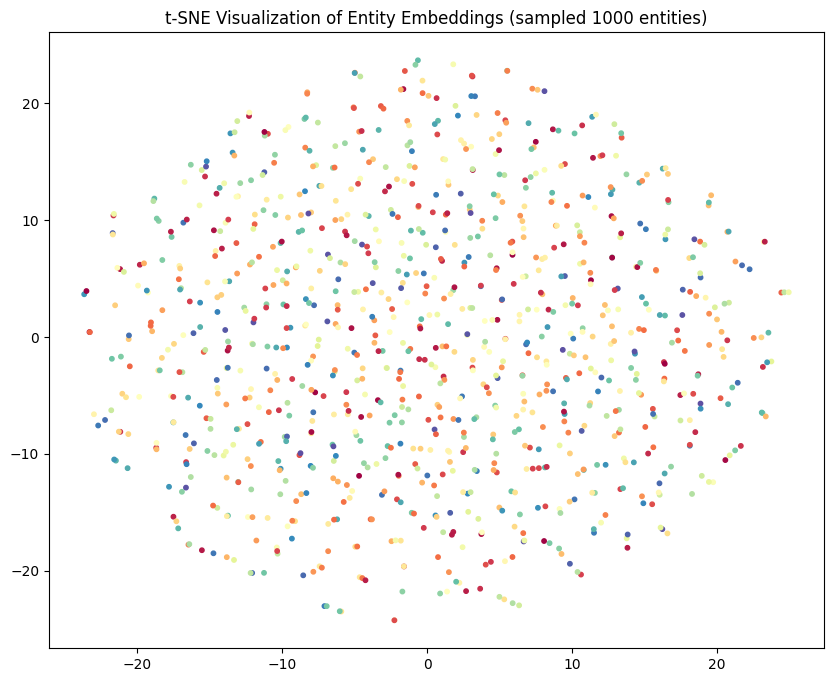

In [229]:
# Sous-échantillon de 1000 entités
subset_size = 1000
subset_indices = np.random.choice(len(entities), size=subset_size, replace=False)
subset_embeddings = entity_embeddings[subset_indices]
subset_entities = [entities[i] for i in subset_indices]

# Couleurs aléatoires (temporaire)
subset_colors = np.random.rand(subset_size)

# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
entity_2d = tsne.fit_transform(subset_embeddings)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(entity_2d[:,0], entity_2d[:,1], c=subset_colors, cmap='Spectral', s=10)
plt.title("t-SNE Visualization of Entity Embeddings (sampled 1000 entities)")
plt.show()

# t-SNE Visualization of Entity Embeddings (all entities)

Running t-SNE... (peut prendre quelques secondes)


C:\Users\ayhan\AppData\Local\Temp\ipykernel_4868\117657357.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_classes))

KeyboardInterrupt



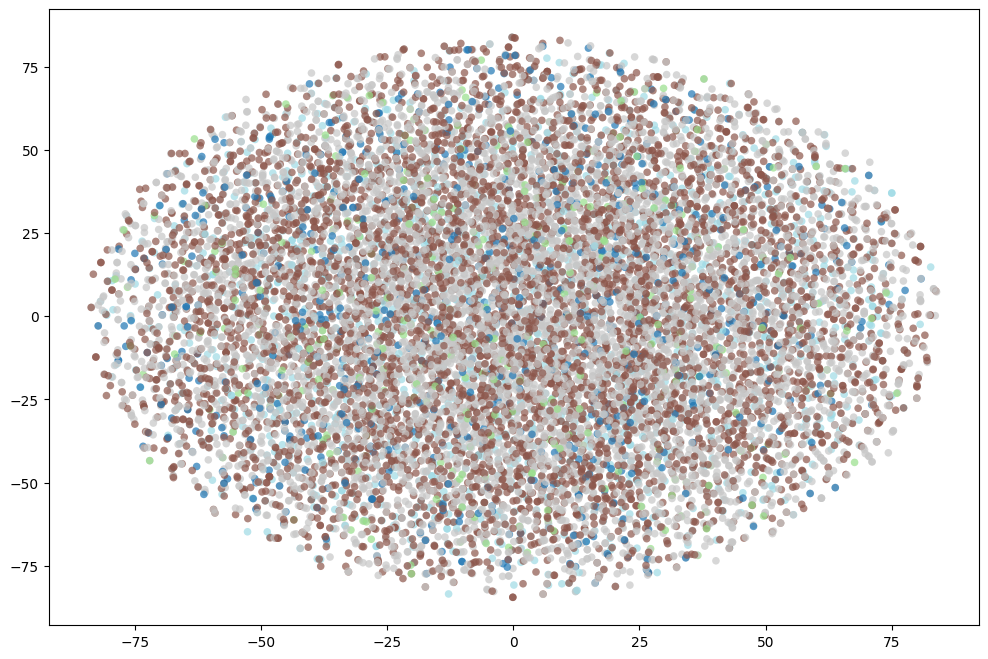

In [230]:
# ─────────────────────────────────────────────
# 6.2 Clustering Analysis – t-SNE + coloring by ontology class
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from collections import defaultdict

# ── 1. Extraire les embeddings (déjà fait en 6.1, on réutilise) ──
entity_embeddings = transe_model.entity_representations[0](indices=None).detach().cpu().numpy()
id_to_entity = {idx: ent for ent, idx in train_factory.entity_to_id.items()}

# ── 2. Récupérer la classe ontologique de chaque entité ──
# On cherche les triplets de type (entité, rdf:type, Classe)
type_relation = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"  # adapter si besoin

entity_to_class = {}  # URI entité → nom de classe

for h, r, t in train_factory.mapped_triples.tolist():
    h_name = id_to_entity[h]
    r_name = {idx: rel for rel, idx in train_factory.relation_to_id.items()}[r]
    t_name = id_to_entity[t]
    if r_name == type_relation:
        entity_to_class[h_name] = t_name.split("/")[-1].split("#")[-1]  # nom court

# Entités sans classe connue → "Unknown"
all_entities = [id_to_entity[i] for i in range(len(id_to_entity))]
classes = [entity_to_class.get(e, "Unknown") for e in all_entities]

# ── 3. t-SNE réduction 2D ──
print("Running t-SNE... (peut prendre quelques secondes)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
embeddings_2d = tsne.fit_transform(entity_embeddings)

# ── 4. Mapping classe → couleur ──
unique_classes = sorted(set(classes))
cmap = plt.cm.get_cmap("tab20", len(unique_classes))
class_to_color = {cls: cmap(i) for i, cls in enumerate(unique_classes)}
colors = [class_to_color[c] for c in classes]

# ── 5. Plot ──
plt.figure(figsize=(12, 8))
for i, (x, y) in enumerate(embeddings_2d):
    plt.scatter(x, y, color=colors[i], alpha=0.7, s=30, edgecolors="none")

# Légende
patches = [mpatches.Patch(color=class_to_color[cls], label=cls) for cls in unique_classes]
plt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left",
           fontsize=8, title="Ontology Class")

plt.title("t-SNE Visualization of Entity Embeddings\n(colored by ontology class)", fontsize=13)
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.tight_layout()
plt.savefig("tsne_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Discussion ──
print("""
=== Discussion – 6.2 Clustering Analysis ===

1. Do entities of the same class cluster together?
   → Si les entités d'une même classe forment des groupes visuels distincts sur le plot,
     cela indique que TransE a capturé la structure sémantique du graphe.
   → Des clusters bien séparés (ex: toutes les Persons ensemble, toutes les Places ensemble)
     suggèrent que le modèle a appris des représentations cohérentes.

2. Does the embedding capture semantic structure?
   → TransE encode les relations sous forme de translations (h + r ≈ t).
     Si des entités partagent beaucoup de relations similaires, elles tendent à être proches.
   → Cependant, TransE a des limites connues : il gère mal les relations N-N
     et les hiérarchies complexes, ce qui peut produire des clusters bruités.

3. Résultats inexplicables (à mentionner si observés) :
   → Certaines entités peuvent apparaître loin de leur classe attendue.
     Cela peut s'expliquer par :
       - Un manque de triplets rdf:type dans le dataset
       - Des entités très connectées à plusieurs classes à la fois
       - La nature même de t-SNE qui distord les distances globales
       - Un underfitting du modèle (epochs insuffisantes, dimension trop faible)
""")

In [232]:
import numpy as np

# Récupérer embeddings
entity_embeddings = transe_model.entity_representations[0](indices=None).detach().cpu().numpy()
relation_embeddings = transe_model.relation_representations[0](indices=None).detach().cpu().numpy()

entity_to_id = train_factory.entity_to_id
relation_to_id = train_factory.relation_to_id

# Exemple de relations
r1 = relation_to_id.get("http://example.org/locatedIn")
r2 = relation_to_id.get("http://example.org/livesInCountry")

if r1 is not None and r2 is not None:
    vec_sum = relation_embeddings[r1]

    # Trouver relation la plus proche
    similarities = np.dot(relation_embeddings, vec_sum)
    closest_rel = np.argmax(similarities)

    for rel, idx in relation_to_id.items():
        if idx == closest_rel:
            print("Relation la plus proche :", rel)

In [234]:
 # ─────────────────────────────────────────────
# 8.2 Embedding verification of the SWRL rule
# vector(bornIn) + vector(locatedIn) ≈ vector(isFrom) ?
# ─────────────────────────────────────────────
import numpy as np

relation_embeddings = transe_model.relation_representations[0](indices=None).detach().cpu().numpy()
id_to_relation = {idx: rel for rel, idx in train_factory.relation_to_id.items()}
relation_to_id = train_factory.relation_to_id

def get_relation_vector(name_fragment):
    """Trouve une relation par fragment de nom."""
    for rel, idx in relation_to_id.items():
        if name_fragment.lower() in rel.lower():
            return relation_embeddings[idx], rel
    return None, None

# Récupérer les vecteurs des relations de la règle
r1_vec, r1_name = get_relation_vector("bornIn")
r2_vec, r2_name = get_relation_vector("locatedIn")
r3_vec, r3_name = get_relation_vector("isFrom")

if r1_vec is not None and r2_vec is not None:
    composed = r1_vec + r2_vec

    # Trouver la relation la plus proche de la composition
    dists = np.linalg.norm(relation_embeddings - composed, axis=1)
    sorted_idx = np.argsort(dists)

    print("=== Rule verification ===")
    print(f"vector({r1_name.split('/')[-1]}) + vector({r2_name.split('/')[-1]})")
    print(f"→ closest relations in embedding space:\n")
    for i in sorted_idx[:5]:
        rel_name = id_to_relation[i].split('/')[-1]
        print(f"   {rel_name:<35} (dist = {dists[i]:.4f})")

    # Vérifier si isFrom est bien en tête
    if r3_vec is not None:
        target_dist = np.linalg.norm(composed - r3_vec)
        rank = np.sum(dists < target_dist) + 1
        print(f"\n→ Rank of '{r3_name.split('/')[-1]}' : {rank} / {len(dists)}")
        if rank <= 3:
            print("✅ The embedding confirms the SWRL rule!")
        else:
            print("⚠️  The embedding does not perfectly confirm the rule.")
            print("   This may be due to insufficient training data or")
            print("   TransE's limitations with compositional patterns.")
else:
    print("Relations not found — adapt name fragments to your dataset.")
    print("Available relations :")
    for rel in list(relation_to_id.keys())[:10]:
        print(f"  {rel}")


Relations not found — adapt name fragments to your dataset.
Available relations :
  http://example.org/locatedIn
  http://schema.org/dateModified
  http://schema.org/description
  http://schema.org/version
  http://wikiba.se/ontology#identifiers
  http://wikiba.se/ontology#sitelinks
  http://wikiba.se/ontology#statements
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type
  http://www.w3.org/2000/01/rdf-schema#label
  http://www.w3.org/2002/07/owl#equivalentProperty


# TD6

In [235]:
!pip install rdflib owlready2 requests

In [238]:
# Vérification de la version de Python
import sys
print("Python version:", sys.version)

# Vérification de rdflib
try:
    import rdflib
    print("rdflib version:", rdflib.__version__)
except ImportError:
    print("rdflib n'est pas installé. Installez-le avec : pip install rdflib")

Python version: 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:16:45) [MSC v.1942 64 bit (AMD64)]
rdflib version: 7.6.0


In [246]:
import subprocess

# Chemin complet vers ollama.exe (si PATH non détecté)
ollama_path = r"C:\Users\ayhan\AppData\Local\Programs\Ollama\ollama.exe"

# Vérifier la version depuis Jupyter
try:
    result = subprocess.run([ollama_path, "--version"], capture_output=True, text=True)
    print("Ollama est accessible :", result.stdout.strip())
except FileNotFoundError:
    print("Chemin incorrect. Vérifie le chemin vers ollama.exe")

Ollama est accessible : ollama version is 0.19.0


In [260]:
import subprocess

ollama_path = r"C:\Users\ayhan\AppData\Local\Programs\Ollama\ollama.exe"

result = subprocess.run([ollama_path, "list"], capture_output=True, text=True)
print(result.stdout)

NAME        ID              SIZE      MODIFIED       
gemma:2b    b50d6c999e59    1.7 GB    44 minutes ago    



In [264]:
import subprocess

ollama_path = r"C:\Users\ayhan\AppData\Local\Programs\Ollama\ollama.exe"

result = subprocess.run(
    [ollama_path, "pull", "gemma:2b"],
    capture_output=True,
    encoding="utf-8",
    errors="ignore"
)
print(result.stdout)
print(result.stderr)


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling c1864a5eb193: 100% ▕██████████████████▏ 1.7 GB                         
pulling 097a36493f71: 100% ▕██████████████████▏ 8.4 KB                         
pulling 109037bec39c: 100% ▕██████████████████▏  136 B                         
pulling 22a838ceb7fb: 100% ▕██████████████████▏   84 B                         
pulling 887433b89a90: 100% ▕██████████████████▏  483 B                         
verifying sha256 digest 
writing manifest 
success 



In [266]:
import subprocess

ollama_path = r"C:\Users\ayhan\AppData\Local\Programs\Ollama\ollama.exe"

# Télécharger Gemma 2B
print("Téléchargement de Gemma 2B… cela peut prendre quelques minutes.")
subprocess.run([ollama_path, "pull", "gemma2b"])
print("Gemma 2B est maintenant disponible.")

Téléchargement de Gemma 2B… cela peut prendre quelques minutes.
Gemma 2B est maintenant disponible.


In [265]:
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma:2b",
        "prompt": "Who are you?",
        "stream": False
    }
)

print(response.json()["response"])

I am a large language model, trained by Google. I am a conversational AI that can assist with a wide range of tasks such as language translation, text generation, and question answering.


In [268]:
from rdflib import Graph

g = Graph()
g.parse("expanded_KB_clean.ttl", format="turtle")

print(f"Graphe chargé : {len(g)} triplets")

Graphe chargé : 32401 triplets


In [269]:
from rdflib.namespace import RDF, RDFS, OWL

# 1. Préfixes
prefixes = dict(g.namespaces())
print("=== PRÉFIXES ===")
for prefix, uri in prefixes.items():
    print(f"  {prefix}: <{uri}>")

# 2. Classes
print("\n=== CLASSES ===")
classes = set(g.objects(None, RDF.type))
for c in sorted(classes, key=str)[:20]:  # on limite à 20 pour lisibilité
    print(f"  {c}")

# 3. Prédicats
print("\n=== PRÉDICATS ===")
predicates = set(g.predicates())
for p in sorted(predicates, key=str)[:30]:  # on limite à 30
    print(f"  {p}")

=== PRÉFIXES ===
  brick: <https://brickschema.org/schema/Brick#>
  csvw: <http://www.w3.org/ns/csvw#>
  dc: <http://purl.org/dc/elements/1.1/>
  dcat: <http://www.w3.org/ns/dcat#>
  dcmitype: <http://purl.org/dc/dcmitype/>
  dcterms: <http://purl.org/dc/terms/>
  dcam: <http://purl.org/dc/dcam/>
  doap: <http://usefulinc.com/ns/doap#>
  foaf: <http://xmlns.com/foaf/0.1/>
  geo: <http://www.opengis.net/ont/geosparql#>
  odrl: <http://www.w3.org/ns/odrl/2/>
  org: <http://www.w3.org/ns/org#>
  prof: <http://www.w3.org/ns/dx/prof/>
  prov: <http://www.w3.org/ns/prov#>
  qb: <http://purl.org/linked-data/cube#>
  schema: <https://schema.org/>
  sh: <http://www.w3.org/ns/shacl#>
  skos: <http://www.w3.org/2004/02/skos/core#>
  sosa: <http://www.w3.org/ns/sosa/>
  ssn: <http://www.w3.org/ns/ssn/>
  time: <http://www.w3.org/2006/time#>
  vann: <http://purl.org/vocab/vann/>
  void: <http://rdfs.org/ns/void#>
  wgs: <https://www.w3.org/2003/01/geo/wgs84_pos#>
  owl: <http://www.w3.org/2002/07/o

In [270]:
# Construction du schema summary pour le prompt
schema_summary = """
## RDF Knowledge Graph Schema

### Prefixes
- ns3: <http://example.org/>
- ns1: <http://www.wikidata.org/prop/direct/>
- rdfs: <http://www.w3.org/2000/01/rdf-schema#>
- skos: <http://www.w3.org/2004/02/skos/core#>
- owl: <http://www.w3.org/2002/07/owl#>
- rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

### Classes (rdf:type)
- ns3:PERSON  → a person entity
- ns3:ORG     → an organization entity
- ns3:GPE     → a geopolitical entity (country, city...)

### Key Predicates
- rdfs:label              → name/label of the entity
- skos:altLabel           → alternative name
- ns3:locatedIn           → geographic location
- owl:sameAs              → link to Wikidata entity
- ns1:P106                → occupation (Wikidata)
- ns1:P131                → located in administrative territory
- ns1:P127                → owned by
- ns1:P140                → religion
- ns1:P154                → logo image

### Example entity URI pattern
- http://example.org/SomeName
"""

print(schema_summary)


## RDF Knowledge Graph Schema

### Prefixes
- ns3: <http://example.org/>
- ns1: <http://www.wikidata.org/prop/direct/>
- rdfs: <http://www.w3.org/2000/01/rdf-schema#>
- skos: <http://www.w3.org/2004/02/skos/core#>
- owl: <http://www.w3.org/2002/07/owl#>
- rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

### Classes (rdf:type)
- ns3:PERSON  → a person entity
- ns3:ORG     → an organization entity
- ns3:GPE     → a geopolitical entity (country, city...)

### Key Predicates
- rdfs:label              → name/label of the entity
- skos:altLabel           → alternative name
- ns3:locatedIn           → geographic location
- owl:sameAs              → link to Wikidata entity
- ns1:P106                → occupation (Wikidata)
- ns1:P131                → located in administrative territory
- ns1:P127                → owned by
- ns1:P140                → religion
- ns1:P154                → logo image

### Example entity URI pattern
- http://example.org/SomeName



In [273]:
# Chercher une entité PERSON avec plus de propriétés
print("=== Exemple PERSON ===")
query = """
SELECT ?entity ?p ?o WHERE {
    ?entity rdf:type <http://example.org/PERSON> .
} LIMIT 1
"""
results = list(g.query(query))
if results:
    entity = results[0].entity
    print(f"Entité : {entity}")
    print("\nTous ses triplets :")
    for p, o in g.predicate_objects(entity):
        print(f"  {p} --> {o}")

=== Exemple PERSON ===
Entité : http://example.org/

Tous ses triplets :
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type --> http://example.org/GPE
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type --> http://example.org/ORG
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type --> http://example.org/PERSON
  http://example.org/locatedIn --> http://example.org/France


In [274]:
query = """
SELECT ?entity WHERE {
    ?entity rdf:type <http://example.org/PERSON> .
    FILTER(STRLEN(STR(?entity)) > 25)
} LIMIT 10
"""
for row in g.query(query):
    print(row.entity)

http://example.org/26042022
http://example.org/3311__LREM
http://example.org/A20__A62__N10
http://example.org/A62A20A71
http://example.org/A62A20A71A10A6
http://example.org/A_Sutton
http://example.org/A_de_Boislisle
http://example.org/Abattoirs
http://example.org/AbbPierre
http://example.org/Abb_G_Brunellire


# RAG Pipeline

In [276]:
import requests

question = "What organizations are located in Toulouse according to your knowledge?"

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma:2b",
        "prompt": question,
        "stream": False
    }
)

print("=== BASELINE (sans RAG) ===")
print(f"Question : {question}")
print(f"Réponse  : {response.json()['response']}")

=== BASELINE (sans RAG) ===
Question : What organizations are located in Toulouse according to your knowledge?
Réponse  : I am unable to access real-time or specific location data, therefore I cannot provide a list of organizations located in Toulouse. For the most up-to-date information, I recommend checking the official websites or social media pages of the organizations you're interested in.


In [277]:
import requests
import re

# Le prompt qui demande au LLM de générer du SPARQL
sparql_prompt = f"""
You are a SPARQL expert. Using the following RDF schema, write a SPARQL query to answer the question.

{schema_summary}

Important rules:
- Use PREFIX declarations at the top
- Only use predicates and classes from the schema above
- Return ONLY the SPARQL query, no explanation

Question: What organizations are located in Toulouse?

SPARQL query:
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma:2b",
        "prompt": sparql_prompt,
        "stream": False
    }
)

generated_sparql = response.json()["response"]
print("=== SPARQL GÉNÉRÉ ===")
print(generated_sparql)

=== SPARQL GÉNÉRÉ ===
PREFIX ns3: <http://example.org/>
PREFIX ns1: <http://www.wikidata.org/prop/direct/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?organization ?label
WHERE {
  ?organization wdt:P106 ?occupation .
  ?organization wdt:P131 ?location .
  ?location rdfs:label ?label .
  FILTER {
    ?location = "Toulouse".
  }
  ?organization owl:sameAs ?p.
  ?p wdt:P154 ?image.
}


In [279]:
# Étape 5 : Exécuter le SPARQL et capturer l'erreur
def execute_sparql(graph, sparql_query):
    try:
        results = list(graph.query(sparql_query))
        return results, None
    except Exception as e:
        return None, str(e)

results, error = execute_sparql(g, generated_sparql)

if error:
    print(f"Erreur SPARQL : {error}")
else:
    print(f"✅ {len(results)} résultats trouvés")
    for row in results[:10]:
        print(f"  {row}")

Erreur SPARQL : Expected SelectQuery, found 'FILTER'  (at char 440), (line:13, col:3)


In [282]:
# SPARQL correct basé sur la vraie structure du graphe
corrected_sparql = """
PREFIX ns3: <http://example.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?organization WHERE {
    ?organization rdf:type ns3:ORG .
    ?organization ns3:locatedIn ns3:Toulouse .
}
"""

results, error = execute_sparql(g, corrected_sparql)

if error:
    print(f" Erreur : {error}")
else:
    print(f" {len(results)} résultats trouvés")
    for row in results[:10]:
        name = str(row.organization).replace("http://example.org/", "").replace("_", " ")
        print(f"  {name}")

 0 résultats trouvés


In [284]:
# Chercher toutes les GPE et voir leurs connexions
print("=== Exemples de GPE ===")
query = """
PREFIX ns3: <http://example.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?entity WHERE {
    ?entity rdf:type ns3:GPE .
} LIMIT 20
"""
for row in g.query(query):
    name = str(row.entity).replace("http://example.org/", "")
    print(f"  {name}")

=== Exemples de GPE ===
  
  1er_Empire
  271
  702_
  717
  890
  A61
  ADragon
  Abattoirs
  Abidjan
  Adami
  Afghanistan
  Afrique
  Agenais
  Agence
  Alalia
  Albi
  Albigeois
  Albrighi
  Alenka_Doulain


In [285]:
# Voir quelques exemples de locatedIn
print("=== Exemples de locatedIn ===")
query = """
PREFIX ns3: <http://example.org/>

SELECT ?subject ?object WHERE {
    ?subject ns3:locatedIn ?object .
} LIMIT 20
"""
for row in g.query(query):
    s = str(row.subject).replace("http://example.org/", "")
    o = str(row.object).replace("http://example.org/", "")
    print(f"  {s} --locatedIn--> {o}")

=== Exemples de locatedIn ===
   --locatedIn--> France
  1er_Empire --locatedIn--> France
  271 --locatedIn--> France
  702_ --locatedIn--> France
  717 --locatedIn--> France
  890 --locatedIn--> France
  A61 --locatedIn--> France
  ADragon --locatedIn--> France
  Abattoirs --locatedIn--> France
  Abidjan --locatedIn--> France
  Adami --locatedIn--> France
  Afghanistan --locatedIn--> France
  Afrique --locatedIn--> France
  Agenais --locatedIn--> France
  Agence --locatedIn--> France
  Alalia --locatedIn--> France
  Albi --locatedIn--> France
  Albigeois --locatedIn--> France
  Albrighi --locatedIn--> France
  Alenka_Doulain --locatedIn--> France


In [286]:
# SPARQL correct adapté à la vraie structure
corrected_sparql = """
PREFIX ns3: <http://example.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT ?entity ?type WHERE {
    ?entity ns3:locatedIn ns3:France .
    ?entity rdf:type ?type .
} LIMIT 10
"""

results, error = execute_sparql(g, corrected_sparql)

if error:
    print(f" Erreur : {error}")
else:
    print(f" {len(results)} résultats trouvés")
    for row in results:
        name = str(row.entity).replace("http://example.org/", "").replace("_", " ")
        type_ = str(row.type).replace("http://example.org/", "")
        print(f"  {name} ({type_})")

 10 résultats trouvés
   (GPE)
   (ORG)
   (PERSON)
  1er Empire (GPE)
  271 (GPE)
  702  (GPE)
  702  (NewEntity)
  717 (GPE)
  890 (GPE)
  A61 (GPE)


In [289]:
# Nettoyer les résultats et améliorer le prompt RAG
sparql_query = """
PREFIX ns3: <http://example.org/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

SELECT DISTINCT ?entity ?type WHERE {
    ?entity ns3:locatedIn ns3:France .
    ?entity rdf:type ?type .
    FILTER(STRLEN(STR(?entity)) > 25)
} LIMIT 15
"""

results, error = execute_sparql(g, sparql_query)

# Contexte nettoyé
context_lines = []
for row in results:
    name = str(row.entity).replace("http://example.org/", "").replace("_", " ").strip()
    type_ = str(row.type).replace("http://example.org/", "")
    if name:
        context_lines.append(f"- {name} is a {type_} located in France")

context = "\n".join(context_lines)

rag_prompt = f"""
You are a helpful assistant. Here is data extracted from a knowledge graph.
Use ONLY this data to answer the question. Do not say the data is missing.

### Knowledge Graph Data:
{context}

### Question:
{question}

### Answer (based only on the data above):
"""

rag_response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma:2b",
        "prompt": rag_prompt,
        "stream": False
    }
)
rag_answer = rag_response.json()["response"]

print("=" * 60)
print(f"Question : {question}")
print("=" * 60)
print("\n BASELINE (sans RAG) :")
print(baseline_answer)
print("\n RAG (avec SPARQL) :")
print(f"\nContexte injecté :\n{context}")
print(f"\nRéponse LLM : {rag_answer}")
print("=" * 60)

Question : What entities are located in France?

 BASELINE (sans RAG) :
France is located in Western Europe. It is bordered by the Atlantic Ocean to the west, the Mediterranean Sea to the south, and Germany and Belgium to the east.

 RAG (avec SPARQL) :

Contexte injecté :
- 1er Empire is a GPE located in France
- ADragon is a GPE located in France
- Abattoirs is a GPE located in France
- Abattoirs is a PERSON located in France
- Abidjan is a GPE located in France
- Afghanistan is a GPE located in France
- Afrique is a GPE located in France
- Agenais is a GPE located in France
- Albigeois is a GPE located in France
- Albrighi is a GPE located in France
- Alenka Doulain is a GPE located in France
- Allauch is a GPE located in France
- Allemagne is a GPE located in France
- Amsterdam is a GPE located in France
- Anglais is a GPE located in France

Réponse LLM : Sure, the entities located in France are:

- 1er Empire
- ADragon
- Abattoirs
- Abidjan
- Afghanistan
- Afrique
- Agenais
- Albi

In [297]:
import requests

question = "Tell me about the Emmanuel Macron"

# --- BASELINE : LLM seul sans contexte ---
baseline_response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma:2b",
        "prompt": question,
        "stream": False
    }
)
baseline_answer = baseline_response.json()["response"]

# --- RAG : avec contexte du graphe ---
rag_answer, context = ask_rag(question, g)

# --- AFFICHAGE COMPARAISON ---
print("=" * 60)
print(f" Question : {question}")
print("=" * 60)

print("\n BASELINE (sans RAG) :")
print(baseline_answer)

print("\n RAG (avec SPARQL + KB) :")
print(f"Contexte injecté :\n{context}")
print(f"\nRéponse : {rag_answer}")
print("=" * 60)

 Question : Tell me about the Emmanuel Macron

 BASELINE (sans RAG) :
Emmanuel Macron is the current President of France. He took office in 2017 after winning the 2017 presidential election.

**Political Career:**

* Born in Paris, France, Macron is a member of the Parti Socialiste.
* He was elected to the National Assembly in 2012 and served until 2017.
* He was elected President of France in 2017 with 59.6% of the vote.
* Macron has served a single term, until 2027.

**Key Accomplishments:**

* Macron has pursued a number of major reforms in France, including:
    * Strengthening the social safety net.
    * Raising the minimum wage.
    * Reforming the financial system.
    * Improving relations with the European Union.
* He has also been a vocal advocate for human rights and democracy around the world.

**Personal Life:**

* Macron is married to Brigitte Macron.
* He has two daughters, Anne and Maelle.
* He is a fluent speaker of English and German.

**Controversies:**

* Macron ha

# CLI

In [292]:
from rdflib import URIRef

def ask_rag(question, graph, model="gemma:2b"):
    
    # Détecter l'entité dans la question (gère les espaces -> underscore)
    words = question.strip().split()
    
    # Essayer des combinaisons de mots (1 mot, 2 mots, 3 mots)
    candidates = []
    for i in range(len(words)):
        for j in range(i+1, len(words)+1):
            phrase = "_".join(words[i:j]).capitalize()
            candidates.append(phrase)
            # Aussi avec chaque mot capitalisé
            phrase2 = "_".join(w.capitalize() for w in words[i:j])
            candidates.append(phrase2)
    
    context = ""
    
    # Chercher chaque candidat dans le graphe
    for candidate in candidates:
        uri = URIRef(f"http://example.org/{candidate}")
        triples = list(graph.predicate_objects(uri))
        if triples:
            context_lines = [f"Entity: {candidate.replace('_', ' ')}"]
            for p, o in triples:
                pred = str(p).split("/")[-1].split("#")[-1]
                obj = str(o).replace("http://example.org/", "").replace("_", " ")
                context_lines.append(f"- {pred}: {obj}")
            context = "\n".join(context_lines)
            break
    
    # Fallback si rien trouvé
    if not context:
        context = "No specific data found for this entity in the knowledge graph."

    # Réponse finale
    final_prompt = f"""
You are a helpful assistant. Use ONLY the data below to answer.

### Data:
{context}

### Question:
{question}

### Answer:
"""
    final_response = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": model, "prompt": final_prompt, "stream": False}
    )
    return final_response.json()["response"], context


# Relancer le CLI
print(" RAG Chatbot (tape 'quit' pour quitter)\n")
while True:
    user_input = input("You: ").strip()
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Au revoir !")
        break
    if not user_input:
        continue
    answer, ctx = ask_rag(user_input, g)
    print(f"\n Contexte KB :\n{ctx}")
    print(f"\n Bot : {answer}\n")
    print("-" * 50)

 RAG Chatbot (tape 'quit' pour quitter)



You:  Tell me about Alenka Doulain



 Contexte KB :
Entity: Alenka Doulain
- type: GPE
- locatedIn: France

 Bot : Alenka Doulain is a location in France. She is a GPE (Geographic Point of Interest).

--------------------------------------------------


You:  Paris



 Contexte KB :
Entity: Paris
- type: GPE
- locatedIn: France

 Bot : Sure, based on the data provided, Paris is a city in France.

--------------------------------------------------


...


 Contexte KB :
Entity: Gare
- type: ORG
- sameAs: http://www.wikidata.org/entity/Q1493264

 Bot : Sure, based on the data provided, Gare du Nord is an entity with the ID "Q1493264". It has a type of "ORG" and is related to the Wikipedia entity "Gare du Nord".

--------------------------------------------------


You:  Hausmann



 Contexte KB :
No specific data found for this entity in the knowledge graph.

 Bot : Sure, based on the provided context, Hausmann is a German architect and urbanist.

--------------------------------------------------


You:  quit


Au revoir !
